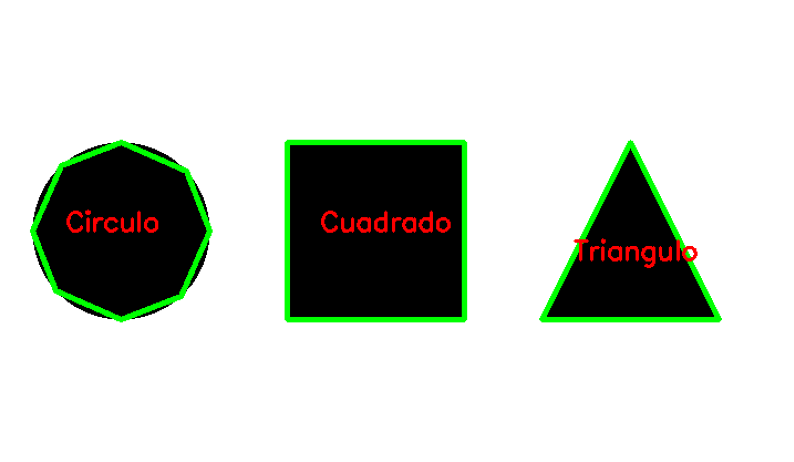

In [1]:
import cv2
import matplotlib.pyplot as plt

imagen = cv2.imread("fig.png")

imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

_, binaria = cv2.threshold(
    gris,
    100,
    255,
    cv2.THRESH_BINARY_INV
)

contornos, _ = cv2.findContours(
    binaria,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for contorno in contornos:

    area = cv2.contourArea(contorno)

    if area < 500:
        continue

    perimetro = cv2.arcLength(contorno, True)

    aproximacion = cv2.approxPolyDP(
        contorno,
        0.02 * perimetro,
        True
    )

    vertices = len(aproximacion)

    figura = "Circulo"

    if vertices == 3:
        figura = "Triangulo"

    elif vertices == 4:
        figura = "Cuadrado"

    momentos = cv2.moments(contorno)

    cx = int(momentos["m10"] / momentos["m00"])
    cy = int(momentos["m01"] / momentos["m00"])

    cv2.drawContours(
        imagen_rgb,
        [aproximacion],
        -1,
        (0, 255, 0),
        3
    )

    cv2.putText(
        imagen_rgb,
        figura,
        (cx - 50, cy),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(10,6))
plt.imshow(imagen_rgb)
plt.axis("off")
plt.show()